Found classes: ['Ё', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']
  Class Ё: loaded 1008 images
  Class А: loaded 1033 images
  Class Б: loaded 496 images
  Class В: loaded 688 images
  Class Г: loaded 816 images
  Class Д: loaded 1102 images
  Class Е: loaded 1024 images
  Class Ж: loaded 976 images
  Class З: loaded 1136 images
  Class И: loaded 896 images
  Class Й: loaded 915 images
  Class К: loaded 876 images
  Class Л: loaded 1002 images
  Class М: loaded 738 images
  Class Н: loaded 1092 images
  Class О: loaded 969 images
  Class П: loaded 980 images
  Class Р: loaded 1010 images
  Class С: loaded 1020 images
  Class Т: loaded 1041 images
  Class У: loaded 1068 images
  Class Ф: loaded 1140 images
  Class Х: loaded 1116 images
  Class Ц: loaded 1079 images
  Class Ч: loaded 1031 images
  Class Ш: loaded 1149 images
  Class Щ: loaded 1156 images
  Class Ъ: loaded 1

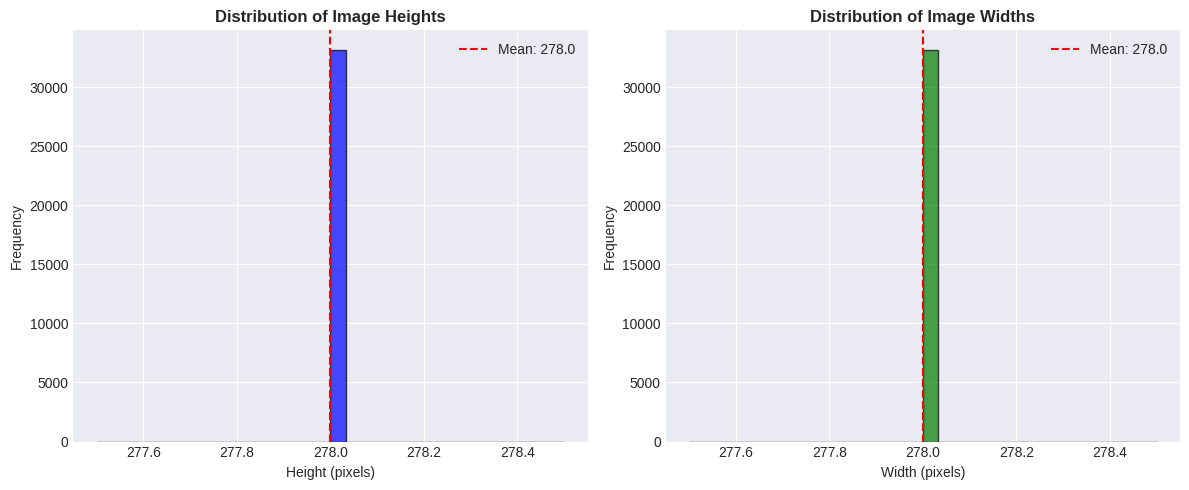


=== IMAGE SIZE STATISTICS ===
Unique heights: [278]
Unique widths: [278]
Height range: 278 - 278 px
Width range: 278 - 278 px
✓ All images have the SAME size!


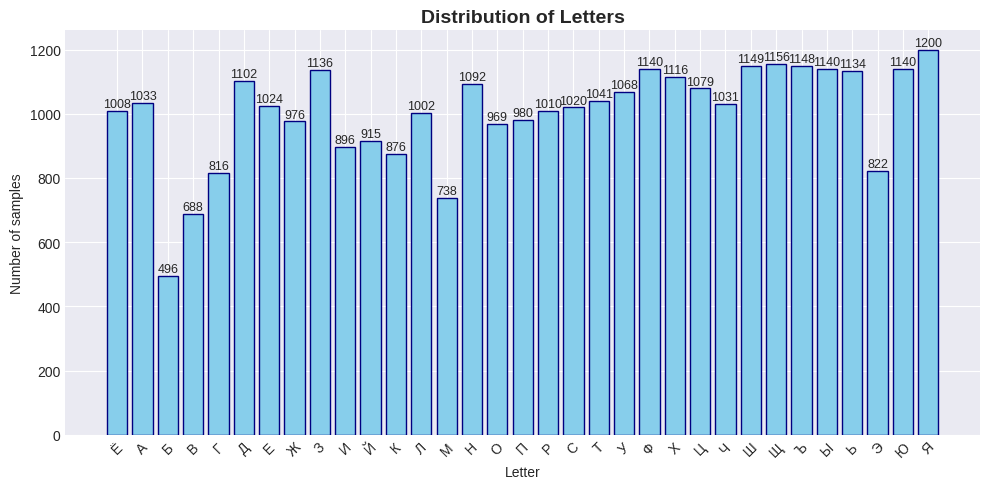


=== CLASS IMBALANCE STATISTICS ===
Total samples: 33141
Mean per class: 1004.3
Min class: Б (496 samples)
Max class: Я (1200 samples)
Imbalance ratio: 2.42


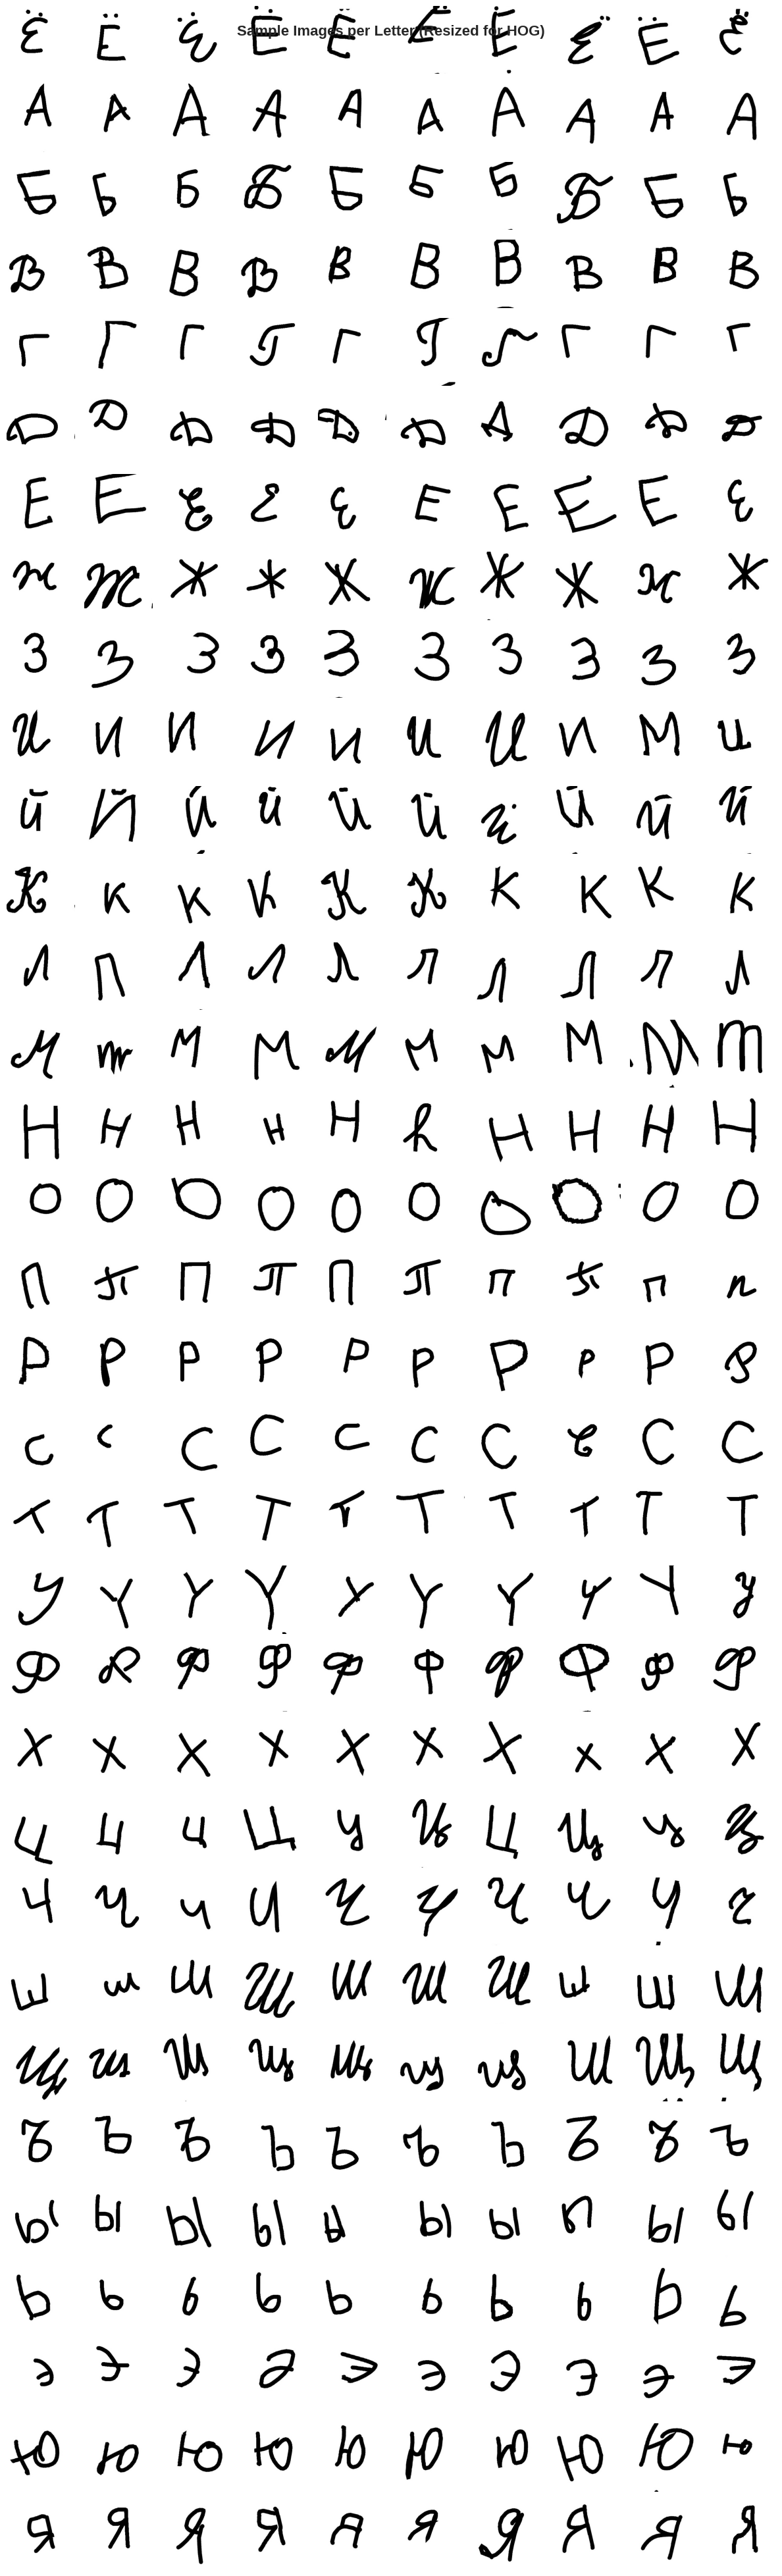

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import cv2
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

def load_letter_data(data_path):
    """Load dataset WITHOUT resizing. Keep original images for analysis."""
    images = []
    labels = []
    class_names = sorted([d.name for d in Path(data_path).iterdir() if d.is_dir()])
    
    print(f"Found classes: {class_names}")
    
    extensions = ['*.jpeg', '*.jpg', '*.png', '*.bmp', '*.JPG', '*.JPEG']
    
    for class_idx, class_name in enumerate(class_names):
        class_path = Path(data_path) / class_name
        count = 0
        
        for ext in extensions:
            for img_path in class_path.glob(ext):
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    images.append(img)
                    labels.append(class_idx)
                    count += 1
        
        print(f"  Class {class_name}: loaded {count} images")
    
    print(f"Total loaded: {len(images)} images")
    return images, np.array(labels), class_names

images_list, y, classes = load_letter_data('../dataset')
print(f"Number of images: {len(images_list)}")

def analyze_image_sizes(images_list):
    """Analyze original image dimensions"""
    heights = [img.shape[0] for img in images_list]
    widths = [img.shape[1] for img in images_list]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].hist(heights, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Distribution of Image Heights', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Height (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(np.mean(heights), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(heights):.1f}')
    axes[0].legend()
    
    axes[1].hist(widths, bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_title('Distribution of Image Widths', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Width (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(np.mean(widths), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(widths):.1f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== IMAGE SIZE STATISTICS ===")
    print(f"Unique heights: {sorted(set(heights))}")
    print(f"Unique widths: {sorted(set(widths))}")
    print(f"Height range: {min(heights)} - {max(heights)} px")
    print(f"Width range: {min(widths)} - {max(widths)} px")
    
    if len(set(heights)) == 1 and len(set(widths)) == 1:
        print("✓ All images have the SAME size!")
    else:
        print("✗ Images have DIFFERENT sizes")
        
    return heights, widths

heights, widths = analyze_image_sizes(images_list)

def plot_class_distribution(y, classes):
    """Analyze class imbalance"""
    counter = Counter(y)
    counts = [counter.get(i, 0) for i in range(len(classes))]
    
    plt.figure(figsize=(10, 5))
    
    plt.bar(classes, counts, color='skyblue', edgecolor='navy')
    plt.title('Distribution of Letters', fontsize=14, fontweight='bold')
    plt.xlabel('Letter')
    plt.ylabel('Number of samples')
    plt.xticks(rotation=45)
    
    for i, v in enumerate(counts):
        if v > 0:
            plt.text(i, v + max(counts)*0.01, str(v), ha='center', fontsize=9)
        
    plt.tight_layout()
    plt.show()
    
    print("\n=== CLASS IMBALANCE STATISTICS ===")
    print(f"Total samples: {len(y)}")
    print(f"Mean per class: {np.mean(counts):.1f}")
    print(f"Min class: {classes[np.argmin(counts)]} ({min(counts)} samples)")
    print(f"Max class: {classes[np.argmax(counts)]} ({max(counts)} samples)")
    print(f"Imbalance ratio: {max(counts)/min(counts):.2f}")
    
    return counts

counts = plot_class_distribution(y, classes)

def visualize_samples_per_class(X, y, classes, samples_per_class=7):
    """Show examples of each letter (after resizing for HOG)"""
    n_classes = len(classes)
    fig, axes = plt.subplots(n_classes, samples_per_class, 
                             figsize=(samples_per_class * 1.2, max(3, n_classes * 1.2)))
    
    if n_classes == 1:
        axes = axes.reshape(1, -1)
    
    for class_idx, class_name in enumerate(classes):
        class_indices = np.where(y == class_idx)[0]
        
        for sample_idx in range(min(samples_per_class, len(class_indices))):
            img_idx = class_indices[sample_idx]
            ax = axes[class_idx, sample_idx]
            ax.imshow(X[img_idx], cmap='gray')
            ax.axis('off')
            
            if sample_idx == 0:
                ax.set_ylabel(class_name, fontsize=12, fontweight='bold', 
                            rotation=0, labelpad=30, va='center')
    
    plt.suptitle('Sample Images per Letter (Resized for HOG)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples_per_class(images_list, y, classes, samples_per_class=10)